In [ ]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
os.environ["CMB_ML_DATA"] = "/bigdata/cmb_project/data/"
sys.path.append("/bigdata/aankit/lost_in_space/")
os.environ['XDG_CONFIG_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_config'
os.environ['XDG_CACHE_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_cache'



In [2]:
from astropy.config.paths import get_cache_dir
print("Astropy cache dir:", get_cache_dir())  # should print /bigdata/...whatever

Astropy cache dir: /bigdata/cmb_project/xdg_home/xdg_cache/astropy


In [3]:
from time import time
import hydra
from hydra import compose, initialize

from omegaconf import OmegaConf

from cmbml.utils.planck_instrument import make_instrument
from cmbml_utils import PipeAccessor

import pysm3
import pysm3.units as u

import numpy as np

from time import time

from cmbml.core.asset_handlers import HealpyMap

In [4]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None)
cfg = compose(config_name='config_sim', overrides=["+min_obs_beam=0"])  # Only used for the instrument
pa = PipeAccessor(cfg, "raw_in")
sim_det_info = pa.assets_in['deltabandpass'].read()
SIM_INSTRUMENT = make_instrument(cfg=cfg,
                                 det_info=sim_det_info)

In [5]:
PRESET_STRINGS = ["co1",
    "c2",    # c2 is a realization created with CMBLensed
    "d9",    # d9 is recommended by Simons Observatory in the "low complexity foregrounds"
    "s4",    # d9 is recommended by Simons Observatory in the "low complexity foregrounds"
    "f1",    # only option
    "a1",    # only option
    "cib1",  # cib1 is recommended by Simons Observatory for extragalactic components
    "ksz1",  # ksz1 is recommended by Simons Observatory for extragalactic components
    "tsz1",  # tsz1 is recommended by Simons Observatory for extragalactic components
    "rg1"    # rg1 is recommended by Simons Observatory for extragalactic components
]

NSIDE_SKY = 2048  # Should be at least 2 * NSIDE_OUT
NSIDE_OUT = 512

# # Used when making 128 maps
# NSIDE_SKY = 256  # Should be at least 2 * NSIDE_OUT
# NSIDE_OUT = 128

start_time = time()

sky = pysm3.Sky(preset_strings=PRESET_STRINGS, 
                nside=NSIDE_SKY, 
                output_unit=pysm3.units.uK_CMB)

print(f"{time()-start_time:.0f}")

97


In [6]:
runs = 10
selected_freqs = [30, 100, 857]
detectors = [d for d in SIM_INSTRUMENT.dets.values() if d.nom_freq in selected_freqs]
detectors

[Detector(nom_freq=30, fields='I', cen_freq=<Quantity 28.4 GHz>, fwhm=<Quantity 75. arcmin>),
 Detector(nom_freq=100, fields='I', cen_freq=<Quantity 100.89 GHz>, fwhm=<Quantity 43. arcmin>),
 Detector(nom_freq=857, fields='I', cen_freq=<Quantity 866.8 GHz>, fwhm=<Quantity 20.6 arcmin>)]

In [13]:
def make_bandpass(center, width=1.0*u.GHz, n_points=50):
    freqs = center + np.linspace(-3, 3, n_points) * width
    weights = np.exp(-0.5 * ((freqs - center)/width)**2)
    weights /= np.sum(weights)
    return freqs, weights

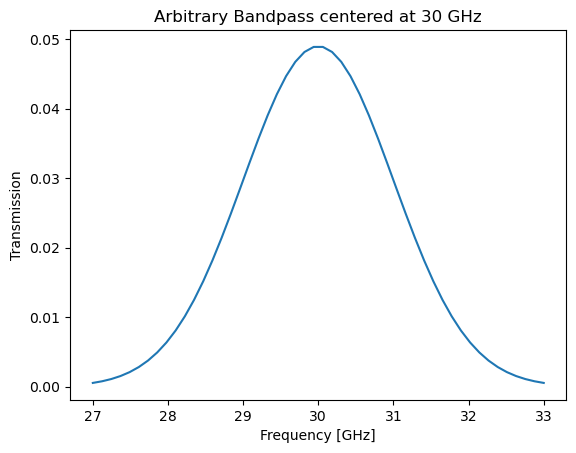

In [14]:
freqs, weights = make_bandpass(30*u.GHz)
import matplotlib.pyplot as plt
plt.plot(freqs, weights)
plt.xlabel("Frequency [GHz]")
plt.ylabel("Transmission")
plt.title("Arbitrary Bandpass centered at 30 GHz")
plt.show()

## Warming up

In [16]:
start_time = time()
_ = sky.get_emission(detectors[0].cen_freq)

freqs, weights = make_bandpass(30*u.GHz, width=1*u.GHz, n_points=50) #random freqs and weights
_ = sky.get_emission(freqs, weights)
print(f"Warm-up time: {time()-start_time:.1f}s")

Warm-up time: 660.9s


## Timinig without bandpass

In [17]:
for det in detectors:
    print(det)

Detector(nom_freq=30, fields='I', cen_freq=<Quantity 28.4 GHz>, fwhm=<Quantity 75. arcmin>)
Detector(nom_freq=100, fields='I', cen_freq=<Quantity 100.89 GHz>, fwhm=<Quantity 43. arcmin>)
Detector(nom_freq=857, fields='I', cen_freq=<Quantity 866.8 GHz>, fwhm=<Quantity 20.6 arcmin>)


In [ ]:
start_time = time()
for run in range(runs):
    run_start = time()
    no_bpi_maps = {}
    for det in detectors:
        t0 = time()
        no_bpi_maps[det.nom_freq] = sky.get_emission(det.cen_freq)
        print(f"        No BP: {det.nom_freq} GHz -> {time()-t0:.2f}s")
    print(f"    Run {run+1}/{runs} time taken: {time()-run_start:.2f}s")
print(f"Total no BP time: {time()-start_time:.0f}s")

        No BP: 30 GHz -> 17.56s
        No BP: 100 GHz -> 90.97s
        No BP: 857 GHz -> 16.71s
    Run 1/10 time taken: 125.24s
        No BP: 30 GHz -> 17.15s
        No BP: 100 GHz -> 17.16s
        No BP: 857 GHz -> 17.24s
    Run 2/10 time taken: 51.56s
        No BP: 30 GHz -> 17.29s
        No BP: 100 GHz -> 17.27s
        No BP: 857 GHz -> 16.92s
    Run 3/10 time taken: 51.48s
        No BP: 30 GHz -> 17.49s
        No BP: 100 GHz -> 17.58s
        No BP: 857 GHz -> 16.88s
    Run 4/10 time taken: 51.96s
        No BP: 30 GHz -> 17.56s
        No BP: 100 GHz -> 17.16s
        No BP: 857 GHz -> 17.39s
    Run 5/10 time taken: 52.12s
        No BP: 30 GHz -> 17.92s
        No BP: 100 GHz -> 17.16s
        No BP: 857 GHz -> 17.20s
    Run 6/10 time taken: 52.29s
        No BP: 30 GHz -> 17.99s
        No BP: 100 GHz -> 17.13s
        No BP: 857 GHz -> 16.85s
    Run 7/10 time taken: 51.98s
        No BP: 30 GHz -> 17.53s
        No BP: 100 GHz -> 17.22s
        No BP: 857 GHz -

## Timing with arbitrary bandpass

In [47]:
start_time = time()

for run in range(runs):
    run_start = time()
    bpi_maps = {}
    for det in detectors:
        t0 = time()
        freqs, weights = make_bandpass(det.cen_freq)
        bpi_maps[det.nom_freq] = sky.get_emission(freqs, weights)
        print(f"        With BP: {det.nom_freq} GHz -> {time()-t0:.2f}s")
    print(f"    Run {run+1}/{runs} time taken: {time()-run_start:.2f}s")
print(f"Total with BP time: {time()-start_time:.2f}s")

        With BP: 30 GHz -> 115.43s
        With BP: 100 GHz -> 156.62s
        With BP: 857 GHz -> 114.66s
    Run 1/10 time taken: 386.71s
        With BP: 30 GHz -> 118.80s
        With BP: 100 GHz -> 117.72s
        With BP: 857 GHz -> 114.88s
    Run 2/10 time taken: 351.40s
        With BP: 30 GHz -> 117.19s
        With BP: 100 GHz -> 117.90s
        With BP: 857 GHz -> 118.79s
    Run 3/10 time taken: 353.88s
        With BP: 30 GHz -> 122.63s
        With BP: 100 GHz -> 116.85s
        With BP: 857 GHz -> 112.23s
    Run 4/10 time taken: 351.72s
        With BP: 30 GHz -> 116.16s
        With BP: 100 GHz -> 119.94s
        With BP: 857 GHz -> 112.78s
    Run 5/10 time taken: 348.88s
        With BP: 30 GHz -> 114.91s
        With BP: 100 GHz -> 114.26s
        With BP: 857 GHz -> 109.75s
    Run 6/10 time taken: 338.93s
        With BP: 30 GHz -> 114.59s
        With BP: 100 GHz -> 114.88s
        With BP: 857 GHz -> 112.07s
    Run 7/10 time taken: 341.54s
        With BP: 30 

## Simulating with real values RIMO LFI

Link - https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

filename = "/bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits"
hdul = fits.open(filename)

bandpass_hdu = hdul['BANDPASS_030-28S']

# Print the column names to see what they are
print(bandpass_hdu.columns.names)
# Example output: ['FREQ', 'RESPONSE', 'WEIGHT', 'NAME'] or similar


['WAVENUMBER', 'TRANSMISSION', 'UNCERTAINITY', 'FLAG']


In [34]:
c_cm_s = 2.99792458e10  # speed of light in cm/s
freqs = (bandpass_hdu.data['WAVENUMBER'] * c_cm_s / 1e9)*u.GHz
weights = bandpass_hdu.data['TRANSMISSION']
weights /= np.sum(weights)

In [10]:
len(freqs)

188

In [44]:
run = 10

for run in range(runs):
    t0 = time()
    maps_rimo = {}
    for d in detectors:
        maps_rimo[d.nom_freq] = sky.get_emission(freqs, weights)
        print(f"        With BP: {det.nom_freq} GHz -> {time()-t0:.2f}s")
    print(f"    Run {run+1}/{runs} time taken: {time()-t0:.2f}s")
print(f"Total with BP time: {time()-start_time:.2f}s")

        With BP: 857 GHz -> 113.38s
        With BP: 857 GHz -> 231.29s
        With BP: 857 GHz -> 351.40s
    Run 1/10 time taken: 351.40s
        With BP: 857 GHz -> 115.93s
        With BP: 857 GHz -> 231.03s
        With BP: 857 GHz -> 345.48s
    Run 2/10 time taken: 345.48s
        With BP: 857 GHz -> 114.83s
        With BP: 857 GHz -> 228.50s
        With BP: 857 GHz -> 341.61s
    Run 3/10 time taken: 341.61s
        With BP: 857 GHz -> 113.41s
        With BP: 857 GHz -> 226.50s
        With BP: 857 GHz -> 339.35s
    Run 4/10 time taken: 339.35s
        With BP: 857 GHz -> 112.94s
        With BP: 857 GHz -> 225.72s
        With BP: 857 GHz -> 338.58s
    Run 5/10 time taken: 338.58s
        With BP: 857 GHz -> 112.94s
        With BP: 857 GHz -> 225.84s
        With BP: 857 GHz -> 338.36s
    Run 6/10 time taken: 338.36s
        With BP: 857 GHz -> 113.50s
        With BP: 857 GHz -> 227.14s
        With BP: 857 GHz -> 339.67s
    Run 7/10 time taken: 339.67s
        With 

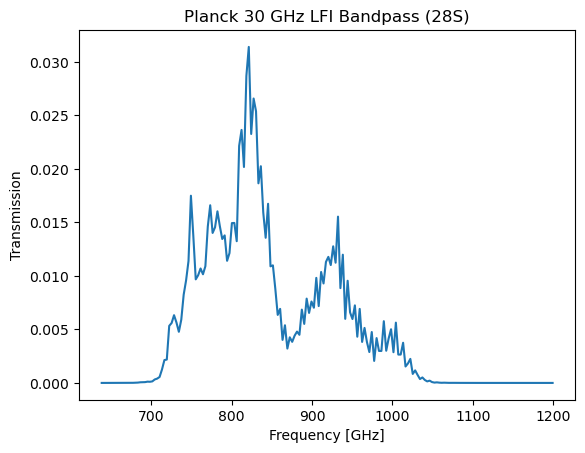

In [14]:
import matplotlib.pyplot as plt
plt.plot(freqs, weights)
plt.xlabel("Frequency [GHz]")
plt.ylabel("Transmission")
plt.title("Planck 30 GHz LFI Bandpass (28S)")
plt.show()